In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

In [2]:
X, y = make_regression(n_features=1, n_samples=100, n_informative=1, n_targets=1, noise=20, random_state=23)

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

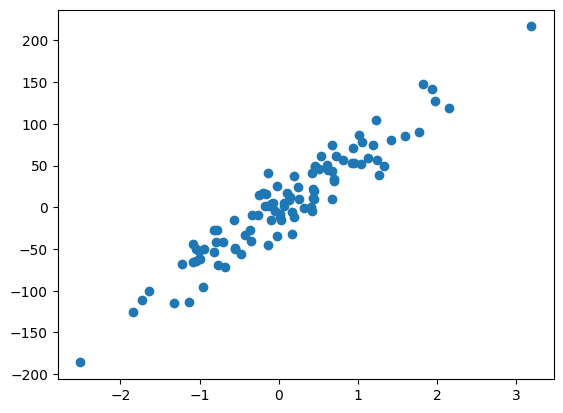

In [5]:
plt.scatter(X, y)
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print(lr.coef_)
print(lr.intercept_)

[61.98986086]
-0.8197871129038203


In [8]:
from sklearn.linear_model import Ridge

In [9]:
rr = Ridge(alpha=10)
rr.fit(X_train, y_train)
print(rr.coef_)
print(rr.intercept_)

[53.68148232]
0.209979418913127


In [10]:
rr1 = Ridge(alpha=100)
rr1.fit(X_train, y_train)
print(rr1.coef_)
print(rr1.intercept_)

[24.33152566]
3.847705233860835


In [11]:
from sklearn.metrics import r2_score

In [12]:
y_pred = rr1.predict(X_test)
r2_score(y_test, y_pred)

0.5486146485303243

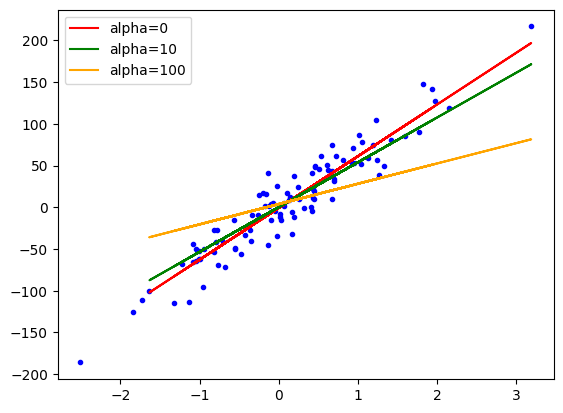

In [13]:
plt.plot(X, y, "b.")
plt.plot(X_train, lr.predict(X_train), c= "red", label= "alpha=0")
plt.plot(X_train, rr.predict(X_train), c = "green", label = "alpha=10")
plt.plot(X_train, rr1.predict(X_train), c = "orange", label = "alpha=100")
plt.legend()
plt.show()

In [14]:
class NarutoRidge:

    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):
        num = 0
        den = 0 
        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean()) * (X_train[i] - X_train.mean())
            den = den + (X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean())

        self.m = num/ (den + self.alpha)
        self.b = y_train.mean() - (self.m * X_train.mean())
        print(self.m, self.b)

    def predict(self, X_test):
        return np.dot(X_test, self.m ) + self.b

        

In [15]:
reg = NarutoRidge(alpha=100)

In [16]:
reg.fit(X_train, y_train)

[24.33152566] [3.84770523]


In [17]:
y_pred1 = reg.predict(X_test)
r2_score(y_test, y_pred1)

0.5486146485303243

# Now we will do this for n-dimension columns

In [18]:
from sklearn.datasets import load_diabetes

In [19]:
X, y = load_diabetes(return_X_y=True)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

In [21]:
red = Ridge(alpha=0.1, solver="cholesky")
red.fit(X_train, y_train)
y_pred2 = red.predict(X_test) 

In [22]:
r2_score(y_test, y_pred2)

0.46699484067579344

In [23]:
print(red.coef_)
print(red.intercept_)

[  -2.69095639 -233.44413235  470.52984991  289.80702001  -77.44092592
  -73.76897522 -180.20544881  149.62422505  447.79211534  102.11390943]
151.38936755774745


In [24]:
class itachiRidge:

    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X_train, y_train):
        X_train = np.insert(X_train, 0, 1, axis=1)
        I = np.identity(X_train.shape[1])
        result = np.linalg.inv(np.dot(X_train.T, X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]

    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

In [25]:
regg = itachiRidge()

In [26]:
regg.fit(X_train, y_train)

In [27]:
y_pred3 = regg.predict(X_test)

In [28]:
r2_score(y_test, y_pred3)

0.46694438662058446

In [29]:
print(regg.coef_)
print(regg.intercept_)

[  -2.72357395 -233.43032232  470.52999737  289.81548292  -77.43043127
  -73.74502183 -180.18665639  149.58771139  447.77140136  102.0819129 ]
151.3461401843336


In [30]:
class itachiRidge1:

    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X_train, y_train):
        X_train = np.insert(X_train, 0, 1, axis=1)
        I = np.identity(X_train.shape[1])
        I[0][0] = 0
        result = np.linalg.inv(np.dot(X_train.T, X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]

    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

In [31]:
rid = itachiRidge1()

In [32]:
rid.fit(X_train, y_train)

In [33]:
y_pred4 = rid.predict(X_test)

In [34]:
r2_score(y_test, y_pred4)

0.46699484067579367

# Ridge regression using gradient descent

In [113]:
X, y = load_diabetes(return_X_y=True)

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

In [115]:
from sklearn.linear_model import SGDRegressor

In [116]:
sgd = SGDRegressor(penalty="l2", max_iter=500, eta0=0.1, learning_rate="constant", alpha=0.001)

In [117]:
sgd.fit(X_train, y_train)
y_pred = sgd.predict(X_test)
print(r2_score(y_test, y_pred))
print(sgd.coef_)
print(sgd.intercept_)

0.40130289364787064
[  20.84957276 -139.38502511  351.07390162  221.02639635   -2.02826642
  -42.10304552 -182.1249103   142.2176536   315.68667646  137.80803092]
[140.79233524]


In [118]:
from sklearn.linear_model import Ridge

In [119]:
ridge = Ridge(alpha=0.001, max_iter=500, solver="sparse_cg")

In [120]:
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
print(r2_score(y_test, y_pred))
print(ridge.coef_)
print(ridge.intercept_)

0.4604257586308249
[ -18.88541983 -271.45568053  518.67957852  325.20999191 -872.05786092
  519.25049729  162.35525976  248.0137083   781.79229843   77.93858528]
151.53138518668473


In [152]:
class obitoRidge:

    def __init__(self, epochs, learning_rate, alpha=0.001):
        self.alpha = alpha
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X_train, y_train):
        self.coef_ = np.ones(X_train.shape[1])
        self.intercept_ = 0
        # thetha is W
        thetha = np.insert(self.coef_, 0, self.intercept_)
        #thetha = np.concatenate(([self.intercept_], self.coef_))

        X_train = np.insert(X_train, 0, 1, axis=1)

        for i in range(self.epochs):
            thetha_der = np.dot(X_train.T, X_train).dot(thetha) - np.dot(X_train.T, y_train) + self.alpha * thetha
            thetha = thetha - (self.learning_rate * thetha_der)

        self.coef_ = thetha[2:]
        self.intercept_ = thetha[0]
        print(thetha)
        
    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_
    

In [44]:
coef_ = np.ones(X_train.shape[1])

In [45]:
coef_

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [48]:
intercept_ = 0

In [49]:
thetha = np.insert(coef_, 0, intercept_)

In [50]:
thetha

array([0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [51]:
X_train = np.insert(X_train, 0, 1, axis=1)

In [52]:
X_train

array([[ 1.        ,  0.08529891,  0.05068012, ..., -0.00259226,
         0.00286131, -0.02593034],
       [ 1.        ,  0.00538306,  0.05068012, ..., -0.00259226,
         0.03839393, -0.01350402],
       [ 1.        , -0.00188202, -0.04464164, ...,  0.08486339,
         0.08449153,  0.04862759],
       ...,
       [ 1.        ,  0.00538306,  0.05068012, ...,  0.03430886,
         0.01255119,  0.09419076],
       [ 1.        , -0.0382074 ,  0.05068012, ...,  0.071948  ,
         0.05028067,  0.06933812],
       [ 1.        , -0.0382074 , -0.04464164, ..., -0.03949338,
        -0.01599887, -0.04249877]])

In [153]:
orid = obitoRidge(epochs=500, learning_rate=0.0005, alpha=0.01)

In [154]:
orid.fit(X_train, y_train)

[149.48969112  34.91551191  -8.2955901  140.73870764 100.48636863
  41.13333158  32.24868627 -92.80040703  97.08591125 136.24261842
  88.07339179]


In [155]:
print(orid.coef_)
print(orid.intercept_)

[ -8.2955901  140.73870764 100.48636863  41.13333158  32.24868627
 -92.80040703  97.08591125 136.24261842  88.07339179]
149.48969112340714


In [156]:
y_pred = orid.predict(X_test)

ValueError: shapes (89,10) and (9,) not aligned: 10 (dim 1) != 9 (dim 0)

In [157]:
r2_score(y_test, y_pred)

0.4604257586308249